IMPORTS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

CONEXION SQL SERVER


In [ ]:
server = 'pwdbddatrpro.estabanell.cat'
database = 'DIST_BASE'
username = 'bdl'
password = 'q7BtUc6jh='

connection_string = (
    f"mssql+pyodbc://{username}:{password}@{server}/{database}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
)

engine = create_engine(connection_string)

QUERY

In [4]:
query= """
SELECT 
    
datalectura,
        sum(activaimport) AS ENERGIA_ENTRANTE,
        sum(activaexport)AS ENERGIA_SALIENTE,
            ct
    FROM contratacion.contratos_atr atr
    INNER JOIN contratacion.contratos_atr_conf conf
        ON conf.contrato_id = atr.id
        --AND GETDATE() BETWEEN conf.fecha_desde AND conf.fecha_hasta
    LEFT JOIN [GIS_ERP].[Estabanell].[public].[CNMC_previ_A4] a4 
        ON atr.cups = a4.cups
    LEFT JOIN [SQLLECTURES.ESTABANELL.CAT].[BDL].[dbo].corbes_fact f 
        ON f.cups = atr.cups
    WHERE 
        datalectura  >= DATEADD(MONTH, -12, DATEFROMPARTS(YEAR(GETDATE()), MONTH(GETDATE()), 1))
  AND datalectura <  DATEFROMPARTS(YEAR(GETDATE()), MONTH(GETDATE()), 1)
        AND tipusmesura = 'H'
        AND ct = 'CT-0710'

		group by ct, datalectura
		ORDER BY DATALECTURA ASC
"""

CARGAR DATAFRAME

In [ ]:
df = pd.read_sql(query, engine)

REVISAR DATOS

In [6]:
df.head()

,datalectura,ENERGIA_ENTRANTE,ENERGIA_SALIENTE,ct
0,2025-06-01 00:00:00,152.572,0.0,CT-0710
1,2025-06-01 01:00:00,141.910,0.0,CT-0710
2,2025-06-01 02:00:00,114.766,0.0,CT-0710
3,2025-06-01 03:00:00,98.791,0.0,CT-0710
4,2025-06-01 04:00:00,84.885,0.0,CT-0710


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8759 entries, 0 to 8758
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   datalectura       8759 non-null   datetime64[ns]
 1   ENERGIA_ENTRANTE  8759 non-null   float64       
 2   ENERGIA_SALIENTE  8759 non-null   float64       
 3   ct                8759 non-null   object        
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 273.8+ KB


In [8]:
df.describe()

,datalectura,ENERGIA_ENTRANTE,ENERGIA_SALIENTE
count,8759,8759.000000,8759.000000
mean,2025-11-30 11:10:30.071926272,221.113212,0.349984
min,2025-06-01 00:00:00,65.189000,0.000000
25%,2025-08-31 05:30:00,132.584500,0.000000
50%,2025-11-30 11:00:00,192.875000,0.000000
75%,2026-03-01 16:30:00,282.460500,0.000000
max,2026-05-31 23:00:00,746.476000,18.708000
std,NaN,115.854401,1.793766


In [9]:
rango_completo = pd.date_range(
    start=df["datalectura"].min(),
    end=df["datalectura"].max(),
    freq="h"
)

In [10]:
for ct in df["ct"].unique():

    subset = df[df["ct"] == ct]

    horas_existentes = subset["datalectura"]

    horas_faltantes = rango_completo.difference(horas_existentes)

    print(f"\n{ct}")

    print(f"Horas faltantes: {len(horas_faltantes)}")


CT-0710
Horas faltantes: 1


INTERPOLACIÓN

In [11]:
resultado = []

for ct in df["ct"].dropna().unique():

    subset = df[df["ct"] == ct].copy()

    subset = subset.set_index("datalectura")

    subset = subset.asfreq("h")

    subset["ct"] = ct

    subset["ENERGIA_ENTRANTE"] = (
        subset["ENERGIA_ENTRANTE"]
        .interpolate(method="time")
    )

    resultado.append(subset.reset_index())

df = pd.concat(resultado, ignore_index=True)

print("Interpolación -> OK (sin horas faltantes)")

Interpolación -> OK (sin horas faltantes)


CONVERTIR FECHA

In [12]:
df["datalectura"] = pd.to_datetime(df["datalectura"])

CREAR VARIABLES TEMPORALEES

In [13]:
df["hora"] = df["datalectura"].dt.hour

df["dia_semana"] = df["datalectura"].dt.dayofweek

df["mes"] = df["datalectura"].dt.month

df["fin_semana"] = df["dia_semana"].isin([5,6]).astype(int)

ORDENAR DATASET POR CT Y FECHA

In [14]:
df = df.sort_values(["ct", "datalectura"])

VALIDACIONES

In [15]:
#NULOS
df.isnull().sum

#DUPLICADOS
df.duplicated().sum()

#VALORES NEGATIVOS
df[df["ENERGIA_ENTRANTE"] < 0]
df[df["ENERGIA_SALIENTE"] < 0]

,datalectura,ENERGIA_ENTRANTE,ENERGIA_SALIENTE,ct,hora,dia_semana,mes,fin_semana


GRÁFICAS TEMPORALES

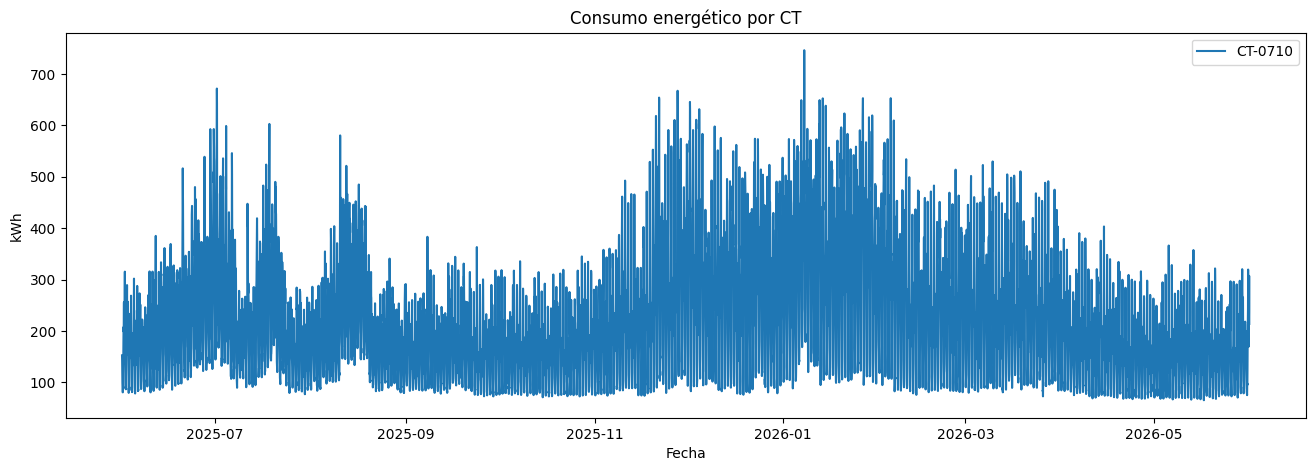

In [16]:
#Consumo por cada CT
plt.figure(figsize=(16,5))

for ct in df["ct"].unique():

    subset = df[df["ct"] == ct]

    plt.plot(
        subset["datalectura"],
        subset["ENERGIA_ENTRANTE"],
        label=ct
    )

plt.title("Consumo energético por CT")
plt.xlabel("Fecha")
plt.ylabel("kWh")
plt.legend()

plt.show()

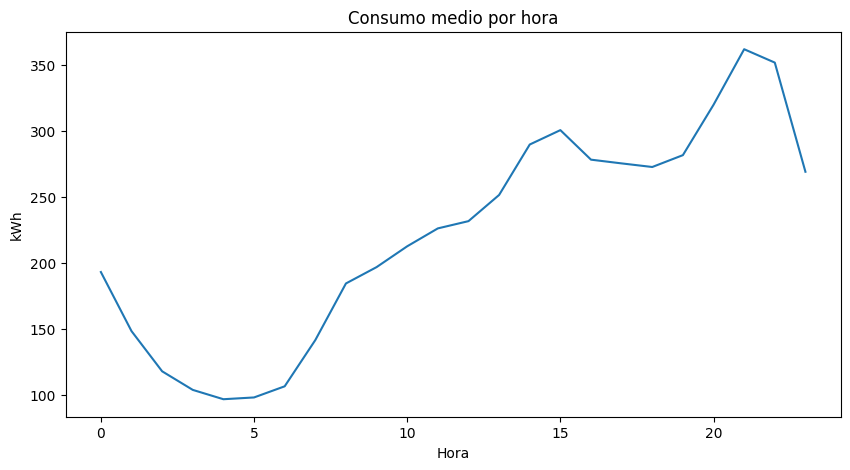

In [17]:
#Consumo medio por hora
consumo_hora = (
    df.groupby("hora")["ENERGIA_ENTRANTE"]
    .mean()
)

plt.figure(figsize=(10,5))

consumo_hora.plot()

plt.title("Consumo medio por hora")
plt.xlabel("Hora")
plt.ylabel("kWh")

plt.show()

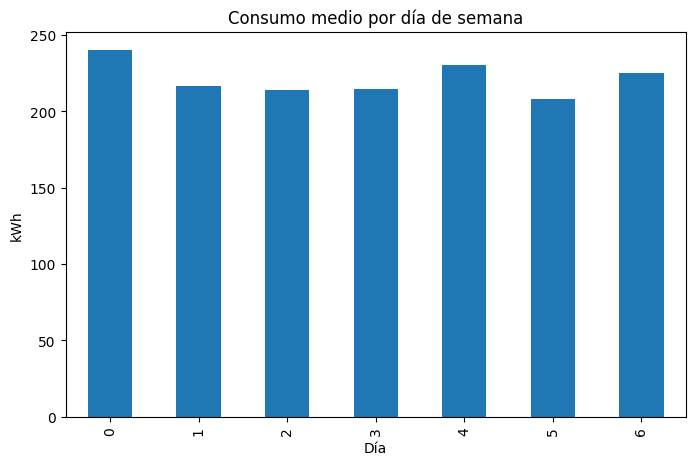

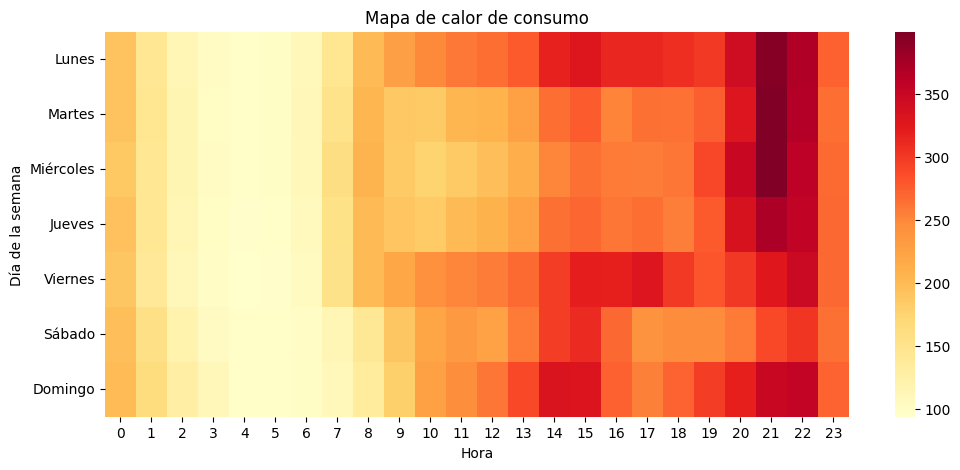

In [24]:
#Mapa de calor horario

pivot = df.pivot_table(
    values="ENERGIA_ENTRANTE",
    index="dia_semana",
    columns="hora",
    aggfunc="mean"
)

plt.figure(figsize=(12,5))

sns.heatmap(pivot,
        cmap="YlOrRd",
        yticklabels=[
        "Lunes",
        "Martes",
        "Miércoles",
        "Jueves",
        "Viernes",
        "Sábado",
        "Domingo"
    ])

plt.title("Mapa de calor de consumo")
plt.xlabel("Hora")
plt.ylabel("Día de la semana")

plt.show()

DATASET LIMPIO

In [20]:
df.to_csv("CCH_dataset.csv", index=False)

C:\Users\ivan.gutierrez\AppData\Local\Temp\ipykernel_22532\3253673312.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


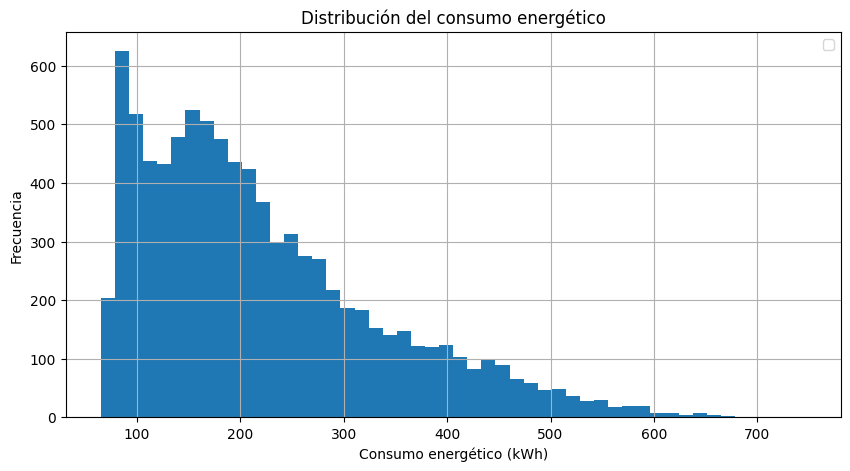

In [ ]:
plt.figure(figsize=(10,5))

df["ENERGIA_ENTRANTE"].hist(bins=50)

plt.title("Distribución del consumo energético")
plt.xlabel("Consumo energético (kWh)")
plt.ylabel("Frecuencia")
plt.legend()